# End-to-End Sales Analytics 

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\SQL COURSE\SampleSuperstore.csv", encoding = "latin1")

In [3]:
print("Shape:", df.shape)

Shape: (9994, 13)


In [6]:
print(df.columns.tolist())
print("\nShape:", df.shape)
df.head(2)

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Shape: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.0,219.5820


In [7]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
# check probles
print("=== NULL VALUES ===")
print(df.isnull().sum())

=== NULL VALUES ===
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [11]:
print("=== DUPLICATE ROWS ===")
print("Duplicates:",df.duplicated().sum())

=== DUPLICATE ROWS ===
Duplicates: 17


In [13]:
print("=== DATA TYPES === ")
print(df.dtypes)

=== DATA TYPES === 
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [15]:
# remove duplicate
df = df.drop_duplicates()

# drop rows hwwre sales or profit is missing
df = df.dropna(subset=['Sales','Profit'])

# remove rows where sales is 0 or neg
df = df[df['Sales'] >0]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (9977, 13)


In [17]:
# add useful columns

# profit margin %
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

# discound bucket ( for analysis)
df['Discount Bucket']=pd.cut(
    df['Discount'],
    bins=[-0.1, 0, 0.2, 0.4, 1.0],
    labels=['No Discount','Low (1-20%)','Medium (21-40%)','high(41%+)']
)
print(df[['Sales','Profit','Profit Margin %', 'Discount Bucket']].head(10))

      Sales    Profit  Profit Margin % Discount Bucket
0  261.9600   41.9136            16.00     No Discount
1  731.9400  219.5820            30.00     No Discount
2   14.6200    6.8714            47.00     No Discount
3  957.5775 -383.0310           -40.00      high(41%+)
4   22.3680    2.5164            11.25     Low (1-20%)
5   48.8600   14.1694            29.00     No Discount
6    7.2800    1.9656            27.00     No Discount
7  907.1520   90.7152            10.00     Low (1-20%)
8   18.5040    5.7825            31.25     Low (1-20%)
9  114.9000   34.4700            30.00     No Discount


In [22]:
print(" FINAL SHAPE")
print(df.shape)

print("\n SALES SUMMARY")
print(df['Sales'].describe().round(2))

print("\n PROFIT SUMMARY")
print(df['Profit'].describe().round(2))
 
print("\n CATEGORY COUNT")
print(df['Category'].value_counts())

print("\n REGION COUNTS")
print(df['Region'].value_counts())

print("\n SEGMENT COUNTS")
print(df['Segment'].value_counts())

 FINAL SHAPE
(9977, 15)

 SALES SUMMARY
count     9977.00
mean       230.15
std        623.72
min          0.44
25%         17.30
50%         54.82
75%        209.97
max      22638.48
Name: Sales, dtype: float64

 PROFIT SUMMARY
count    9977.00
mean       28.69
std       234.46
min     -6599.98
25%         1.73
50%         8.67
75%        29.37
max      8399.98
Name: Profit, dtype: float64

 CATEGORY COUNT
Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

 REGION COUNTS
Region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64

 SEGMENT COUNTS
Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: count, dtype: int64


In [26]:
df.to_csv(r"C:\SQL COURSE\OrdersClean.csv", index=False)
print("Clean data saved to data ")

Clean data saved to data 


# EDA PROCESS


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\SQL COURSE\OrdersClean.csv")
print("Shape:", df.shape)
df.head()

Shape: (9977, 15)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin %,Discount Bucket
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,No Discount
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,No Discount
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,No Discount
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,high(41%+)
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,Low (1-20%)


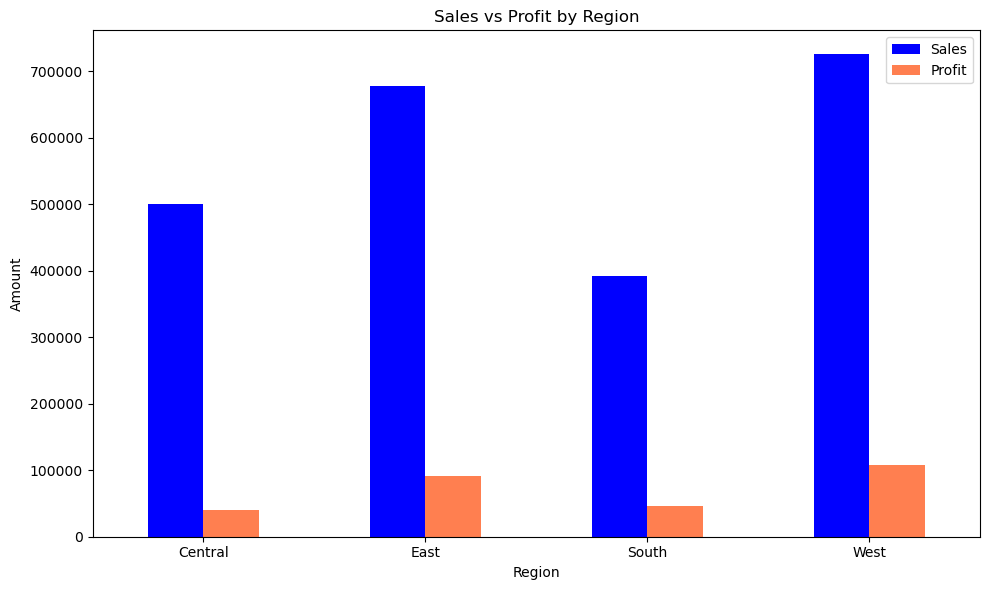

In [5]:
#Sales by region

region_sales = df.groupby('Region')[['Sales','Profit']].sum().round(2)
region_sales.plot(kind='bar', figsize=(10,6), color=['blue','coral'])
plt.title('Sales vs Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(['Sales','Profit'])
plt.tight_layout()
plt.savefig('region_analysis.png')
plt.show()

# Sales by Category

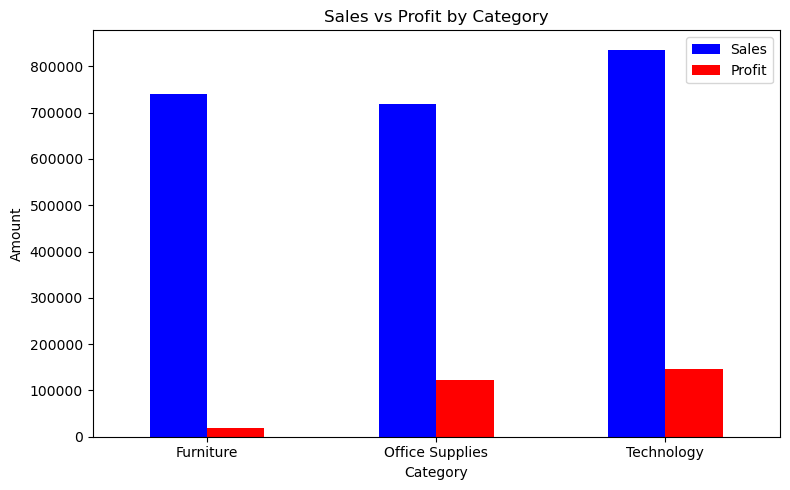

In [9]:
cat_sales = df.groupby('Category')[['Sales','Profit']].sum().round(2)
cat_sales.plot(kind='bar',figsize=(8,5),color=['blue','red'])
plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(['Sales','Profit'])
plt.tight_layout()
plt.savefig('category_analysis.png')
plt.show()

#  Discount vs Profit scatter

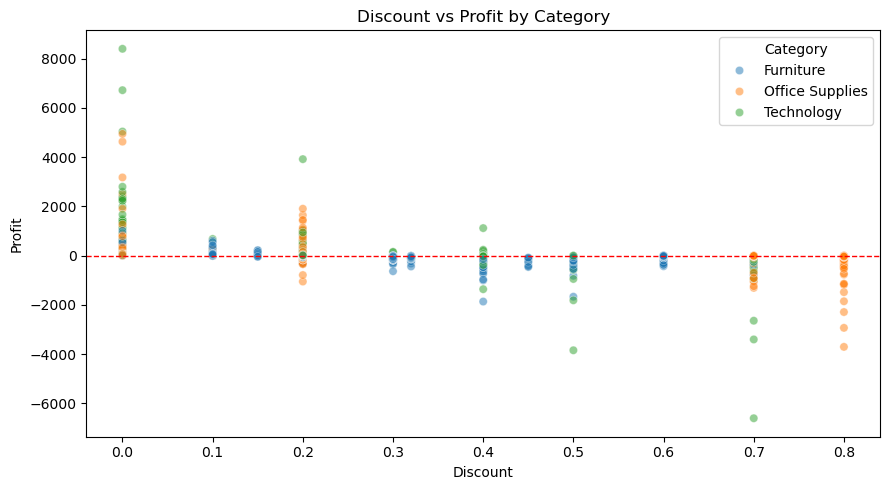

Correlation between Discount and Profit: -0.22


In [10]:
plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df, 
    x='Discount', 
    y='Profit', 
    hue='Category',
    alpha=0.5
)
plt.title('Discount vs Profit by Category')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('discount_profit.png')
plt.show()

print("Correlation between Discount and Profit:", 
      df['Discount'].corr(df['Profit']).round(3))

# Sub-category profit bar chart

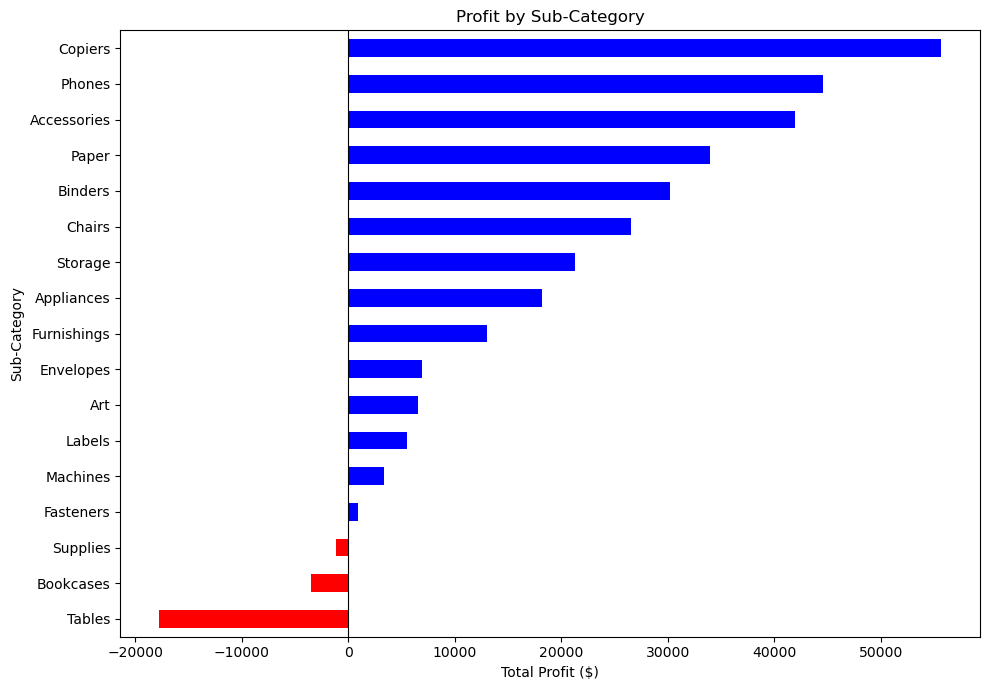

In [13]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,7))
colors = ['red' if x < 0 else 'blue' for x in sub_profit]
sub_profit.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('subcategory_profit.png')
plt.show()

# Segment analysis pie chart

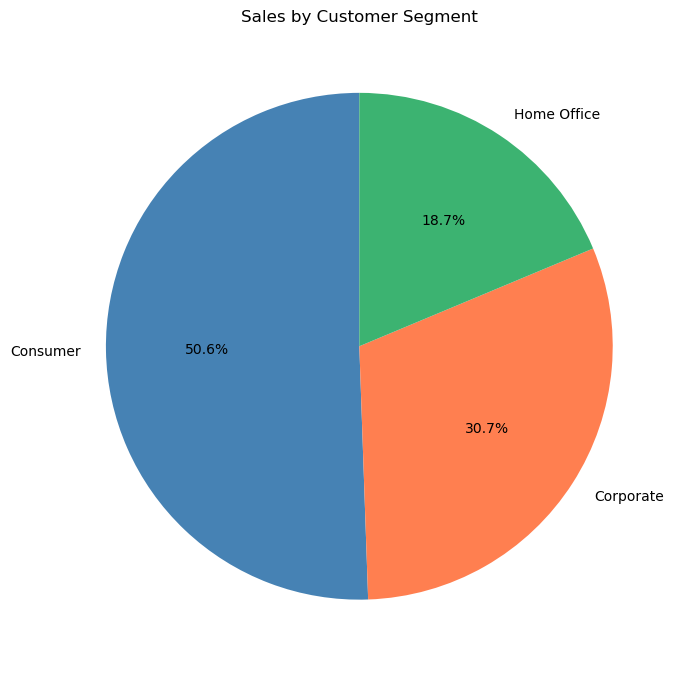

In [14]:
seg = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(seg, labels=seg.index, autopct='%1.1f%%', 
        colors=['steelblue','coral','mediumseagreen'],
        startangle=90)
plt.title('Sales by Customer Segment')
plt.tight_layout()
plt.savefig('segment_analysis.png')
plt.show()